**Part 2: Project Part**

**Q4:** Select a project from the list provided in the document and implement a complete end-to-end machine learning pipeline for the same. Also, prepare a demo using gradio/streamlit for evaluation

I am using **Diabetes Health Indicators**

# **Load Data**   
Downloads and loads the dataset into a Pandas DataFrame.
Downloading, extracting, and loading the dataset into a structured format ensures smooth data processing.

In [4]:
!pip install kagglehub
!pip install kaggle
!mkdir -p ~/.kaggle

In [5]:
import kagglehub
import os

# Download latest version
dataset_path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", dataset_path)
print(os.listdir(dataset_path))

100%|██████████| 6.03M/6.03M [00:00<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1
['diabetes_012_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv']


In [6]:
import pandas as pd

csv_file = [f for f in os.listdir(dataset_path) if f.endswith(".csv")][0]
csv_path = os.path.join(dataset_path, csv_file)

df = pd.read_csv(csv_path)
print(df.shape)
df_copy = df

(253680, 22)



# **Data Visualization**
Generates correlation heatmap and diabetes class distribution plots.
Visualizations to analyze feature relationships and class distributions. Histograms, heatmaps, and bar charts help uncover patterns in the data.*italicised text*

**Data Exploration**

Displays dataset info, summary statistics, and missing values.
An overview of the dataset, including column types, summary statistics, and missing values. Understanding the data helps identify necessary preprocessing steps.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def explore_data(df):
    print("Dataset Info:\n")
    print(df.info())
    print("\nSummary Statistics:\n")
    print(df.describe())
    print("\nMissing Values:\n")
    print(df.isnull().sum())
    duplicates = df.duplicated().sum()
    print(f"Total Duplicate Rows: {duplicates}")

explore_data(df)


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null

In [9]:
# Identifies placeholders used for missing values in the dataset
def check_unrecognized_missing(df):
    is_any_missing = False
    for col in df.columns:
        unique_values = df[col].unique()
        suspicious_values = ["?", "N/A", "None", -1, 9999]
        found = [val for val in suspicious_values if val in unique_values]
        if found:
            print(f"Column '{col}' contains potential missing values: {found}")
            is_any_missing = True

    if is_any_missing == False:
        print("No unrecognized symbol")
# Call the function
check_unrecognized_missing(df)

No unrecognized symbol


**Correlation Heatmap**
Generates a heatmap to visualize feature correlations.  
Identifies relationships between features, helping in feature selection and data preprocessing.  


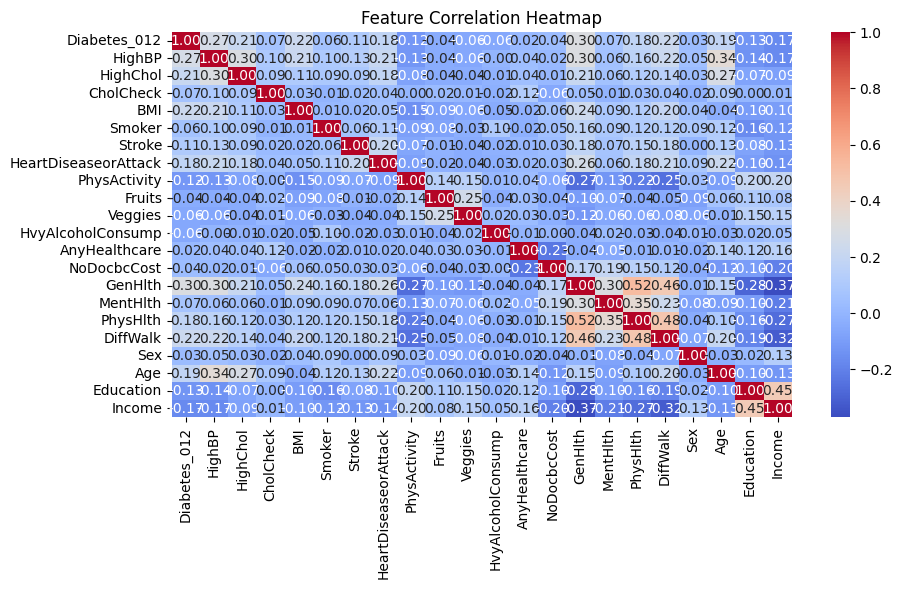

In [10]:
def plot_correlation_heatmap(df):
    """Generates a heatmap to visualize feature correlations."""
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.show()

plot_correlation_heatmap(df)

**Target Variable Distribution**
Generates a heatmap to visualize feature correlations.
Identifies relationships between features, helping in feature selection and data preprocessing.

In [26]:
target_col="Diabetes_012"

<ipython-input-27-9b14fb2ce1d0>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


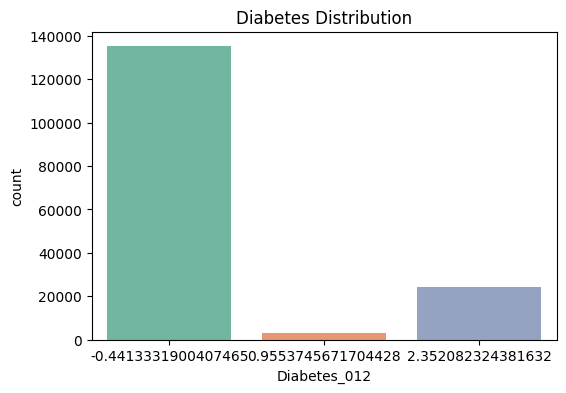

In [27]:
# Generates a bar chart to show the distribution of the target variable.
def plot_target_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette="Set2")
    plt.title("Diabetes Distribution")
    plt.show()

plot_target_distribution(df)

**Feature Distributions**
Generates histograms for numerical features.
Helps understand feature distributions and detect skewness or outliers.

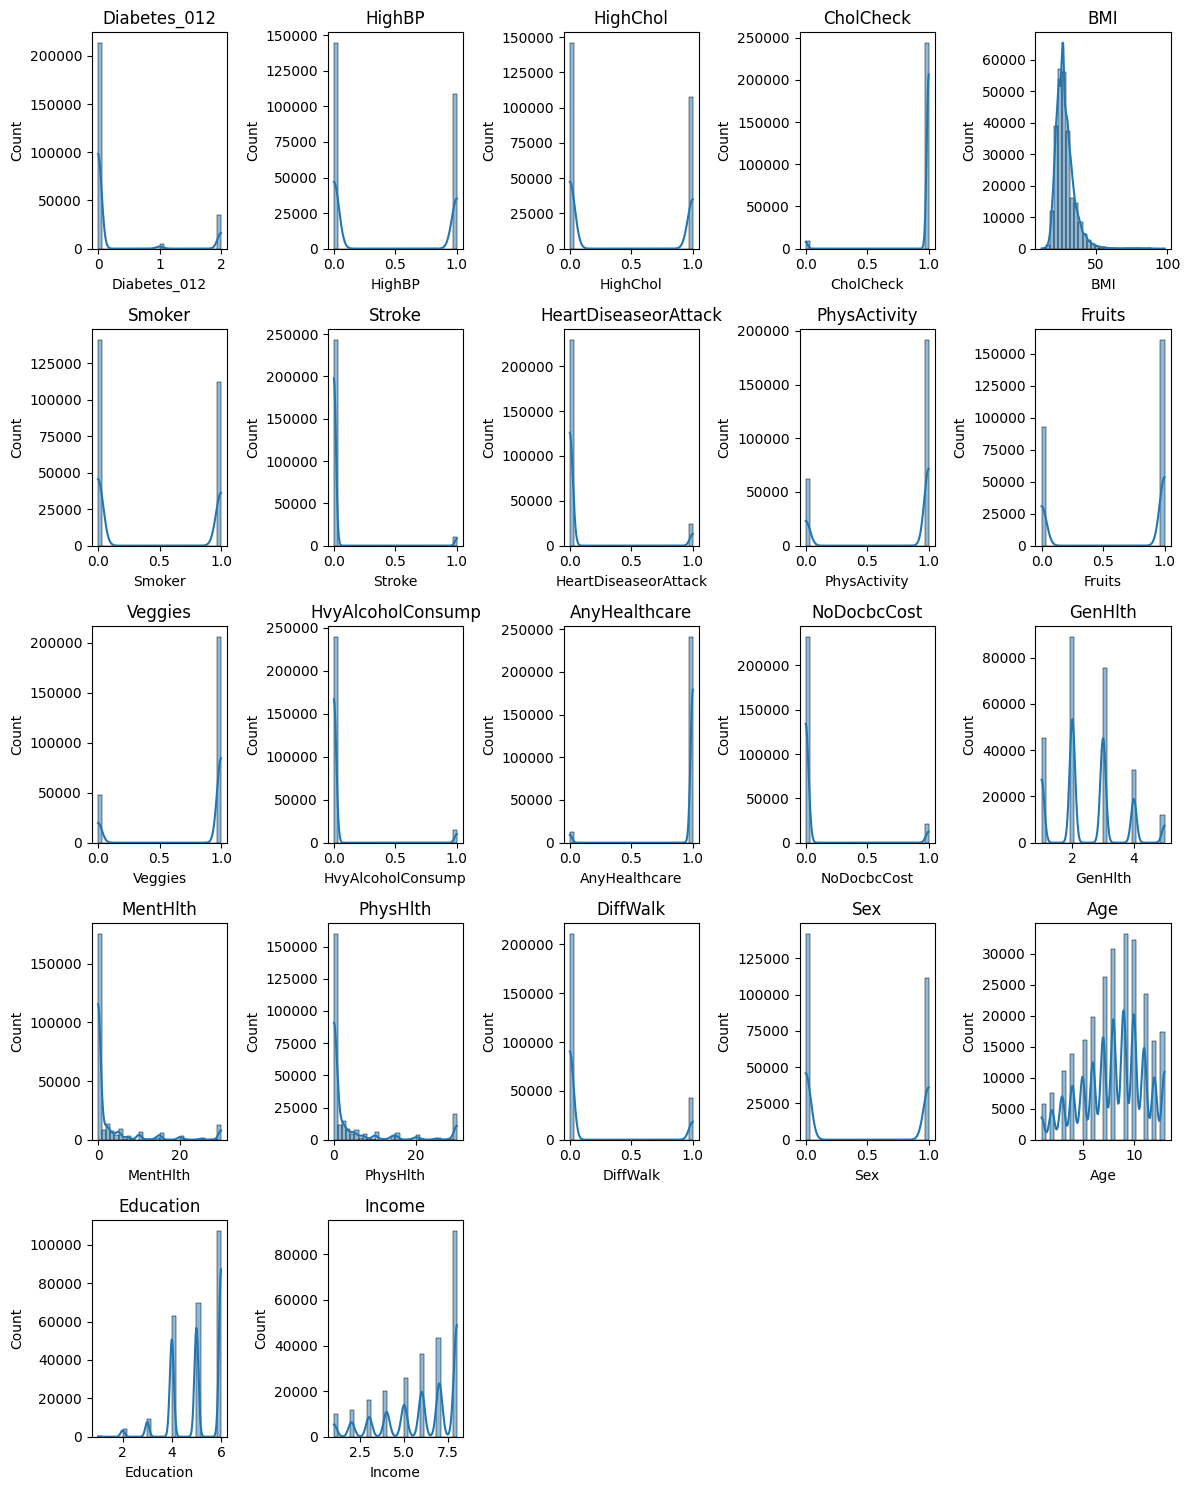

In [16]:
import math

def plot_feature_distributions(df):
    numeric_columns = df.select_dtypes(include=["number"]).columns
    num_features = len(numeric_columns)

    # Calculate subplot layout based on number of features
    num_cols = 5  # Fixed number of columns
    num_rows = math.ceil(num_features / num_cols)  # Calculate number of rows

    # Create figure with appropriate size
    plt.figure(figsize=(12, num_rows * 3))  # Adjust figure height

    # Plot histograms for each numeric feature
    for i, col in enumerate(numeric_columns, 1):
        plt.subplot(num_rows, num_cols, i)  # Position subplot
        sns.histplot(df[col], bins=30, kde=True, edgecolor="black")
        plt.title(col)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

plot_feature_distributions(df)

# **Data Preprocessing**

**Handling Missing Values**
Removes or imputes missing values to ensure data consistency.
Missing values can impact model performance, so handling them is crucial before training.

In [17]:
# Fills missing values with mean and drops columns with ≥70% missing data
def handle_missing_values(df, threshold=0.7):
    print("Missing Values Before Handling:\n", df.isnull().sum())

    # Drop columns with ≥ 70% missing values
    missing_ratio = df.isnull().mean()  # Get percentage of missing values per column
    cols_to_drop = missing_ratio[missing_ratio >= threshold].index
    df.drop(columns=cols_to_drop, inplace=True)

    # Fill missing numerical values with column mean
    df.fillna(df.mean(), inplace=True)

    print("\nDropped Columns:", list(cols_to_drop))
    print("\nMissing Values After Handling:\n", df.isnull().sum())
    return df

# As this data set don't have missing value so no need to call this
# df = handle_missing_values(df)

In [18]:
# Removes duplicate rows from the dataset.
def remove_duplicates(df):
    print("Duplicates Before Removal:", df.duplicated().sum())
    df.drop_duplicates(inplace=True)
    print("Duplicates After Removal:", df.duplicated().sum())
    return df
# Call the function
df = remove_duplicates(df)


Duplicates Before Removal: 23899
Duplicates After Removal: 0


In [19]:
import pandas as pd
import numpy as np
from scipy import stats

# Handles outliers using either Z-score or IQR method
def handle_outliers(df, method="zscore", threshold=3):
  numeric_cols = df.select_dtypes(include=["number"]).columns
  mask = np.ones(len(df), dtype=bool)
  for col in numeric_cols:
    if method == "zscore":
      z_scores = np.abs(stats.zscore(df[col]))
      mask = mask & (z_scores < threshold) # Remove outliers
    elif method == "iqr":
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]  # Remove outliers
    else:
      raise ValueError("Invalid method. Choose 'zscore' or 'iqr'.")
  df = df[mask]
  return df

df = handle_outliers(df, method="zscore", threshold=3)  # or method="iqr"

**Encoding Categorical Variables** Converts categorical data into numerical format for ML models.
Machine learning algorithms require numerical inputs, so categorical values must be transformed

In [20]:
from sklearn.preprocessing import LabelEncoder

# Encodes categorical variables using label encoding.
def encode_categorical(df):
    categorical_cols = df.select_dtypes(include=["object"]).columns
    if len(categorical_cols) == 0:
        print("No categorical columns found.")
        return df

    encoder = LabelEncoder()
    for col in categorical_cols:
        df[col] = encoder.fit_transform(df[col])

    print("Categorical columns encoded:", list(categorical_cols))
    return df

df = encode_categorical(df)

No categorical columns found.


**Feature Scaling** Transforms numerical features to a common scale for better model performance. Scaling ensures that features with different units do not dominate model training.

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scales numerical features using Standardization or Normalization.
def scale_features(df, method="standard"):
    numeric_cols = df.select_dtypes(include=["number"]).columns

    if method == "standard":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("Invalid method. Choose 'standard' or 'minmax'.")

    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    print(f"Features scaled using {method} scaling.")
    return df

# Call the function (choose 'standard' or 'minmax')
df = scale_features(df, method="standard")


Features scaled using standard scaling.


**Feature Selection**
Removes highly correlated or irrelevant features to improve model efficiency.
Feature selection helps reduce dimensionality, prevent overfitting, and improve interpretability.

In [22]:
# Removes highly correlated features based on a threshold.
def select_features(df, corr_threshold=0.85):
    exclude_features = ['Education', 'Income']
    df = df.drop(columns=exclude_features, errors='ignore')
    corr_matrix = df.corr().abs()

    # Mask for the upper triangle (excluding diagonal)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Identify features to drop
    to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] >= corr_threshold)]

    df.drop(columns=to_drop, inplace=True)


    # Filter out excluded features before calculating correlation
    features_to_analyze = [col for col in df.columns
                           if col not in exclude_features + [target_col]] # Assuming target_col is your target variable column
    corr_matrix = df[features_to_analyze].corr().abs()
    print("Dropped Highly Correlated Features:", to_drop)
    return df

df = select_features(df)

Dropped Highly Correlated Features: []


In [28]:
def clean_target_variable(df, target_col="Diabetes_012"):
    """Ensures the target variable contains only 0 and 1."""
    print("Unique values before cleaning:", df[target_col].unique())

    # Clean the target variable
    df[target_col] = np.where(df[target_col] > 0, 1, 0)  # Values > 0 become 1, others become 0

    print("Unique values after cleaning:", df[target_col].unique())
    return df
# Call the function before splitting data
df = clean_target_variable(df, target_col)


Unique values before cleaning: [-0.44133319  2.35208232  0.95537457]
Unique values after cleaning: [0 1]


# **Model Building**   
Trains machine learning models to predict diabetes based on processed features.
This step includes data splitting, model selection, training, and evaluation.

**Splitting Data**
Divides the dataset into training and testing sets for model evaluation.
Ensures the model learns patterns from training data and generalizes to unseen data.

In [30]:
from sklearn.model_selection import train_test_split

# Splits the dataset into training and testing sets.
def split_data(df, test_size=0.2, random_state=42):
    X = df.drop(columns=[target_col])  # Features
    y = df[target_col]  # Target variable

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    print(f"Data split complete: Train ({len(X_train)}), Test ({len(X_test)})")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(df)

Data split complete: Train (129888), Test (32473)


**Model Selection**
Chooses the best machine learning algorithms for diabetes prediction.
Different models like Logistic Regression, Random Forest, and XGBoost are tested for accuracy and efficiency.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Defines the models to be trained and tested.
def select_models():
    models = {
        "Logistic Regression": LogisticRegression(),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier()
    }
    return models

models = select_models()
print("Models selected:", list(models.keys()))


Models selected: ['Logistic Regression', 'Random Forest', 'XGBoost']


**Model Training** Fits selected models to the training data.
Each model learns patterns from the dataset to make predictions.

In [32]:
# Trains multiple models on the training dataset.
def train_models(models, X_train, y_train):
    trained_models = {}

    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        trained_models[name] = model

    print("Model training complete.")
    return trained_models

trained_models = train_models(models, X_train, y_train)


Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Model training complete.


**Model Evaluation** Measures model performance using accuracy, precision, recall, F1-score, and AUC-ROC.
This helps compare models and select the best one for diabetes prediction.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluates trained models on the test dataset.
def evaluate_models(models, X_test, y_test):
    results = {}

    for name, model in models.items():
        print(f"Evaluating {name}...")
        y_pred = model.predict(X_test)

        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_pred)
        }

    return results

evaluation_results = evaluate_models(trained_models, X_test, y_test)

# Print results
for model, metrics in evaluation_results.items():
    print(f"\n{model} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...

Logistic Regression Performance:
Accuracy: 0.8375
Precision: 0.5744
Recall: 0.1653
F1-score: 0.2567
AUC-ROC: 0.5701

Random Forest Performance:
Accuracy: 0.8150
Precision: 0.4127
Recall: 0.2117
F1-score: 0.2799
AUC-ROC: 0.5751

XGBoost Performance:
Accuracy: 0.8362
Precision: 0.5587
Recall: 0.1665
F1-score: 0.2566
AUC-ROC: 0.5698


**Hyperparameter Tuning** Optimizes model parameters to improve performance.
We use GridSearchCV to find the best hyperparameters for each model.

In [34]:
from sklearn.model_selection import GridSearchCV

# Performs hyperparameter tuning using GridSearchCV.
def tune_hyperparameters(models, X_train, y_train):
    tuned_models = {}

    param_grid = {
        "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
        "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]},
        "XGBoost": {"learning_rate": [0.01, 0.1, 0.2], "n_estimators": [50, 100]}
    }

    for name, model in models.items():
        print(f"Tuning {name}...")
        grid_search = GridSearchCV(model, param_grid[name], cv=5, scoring="accuracy", n_jobs=-1)
        grid_search.fit(X_train, y_train)

        tuned_models[name] = grid_search.best_estimator_
        print(f"Best Params for {name}: {grid_search.best_params_}")

    return tuned_models

tuned_models = tune_hyperparameters(trained_models, X_train, y_train)


Tuning Logistic Regression...
Best Params for Logistic Regression: {'C': 0.1}
Tuning Random Forest...


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 100}
Tuning XGBoost...
Best Params for XGBoost: {'learning_rate': 0.1, 'n_estimators': 50}


In [35]:
evaluation_results_tuned = evaluate_models(tuned_models, X_test, y_test)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...


In [36]:
# Compares model performance before and after tuning
def compare_model_performance(before, after):
    print("\n### Model Performance Comparison ###")

    for model in before.keys():
        print(f"\n{model} Performance:")
        print(f"{'Metric':<12} | Before Tuning | After Tuning")
        print("-" * 40)

        for metric in before[model].keys():
            before_val = before[model][metric]
            after_val = after[model][metric]
            print(f"{metric:<12} | {before_val:.4f}      | {after_val:.4f}")


compare_model_performance(evaluation_results, evaluation_results_tuned)



### Model Performance Comparison ###

Logistic Regression Performance:
Metric       | Before Tuning | After Tuning
----------------------------------------
Accuracy     | 0.8375      | 0.8375
Precision    | 0.5744      | 0.5742
Recall       | 0.1653      | 0.1649
F1-score     | 0.2567      | 0.2562
AUC-ROC      | 0.5701      | 0.5700

Random Forest Performance:
Metric       | Before Tuning | After Tuning
----------------------------------------
Accuracy     | 0.8150      | 0.8384
Precision    | 0.4127      | 0.6490
Recall       | 0.2117      | 0.1047
F1-score     | 0.2799      | 0.1803
AUC-ROC      | 0.5751      | 0.5466

XGBoost Performance:
Metric       | Before Tuning | After Tuning
----------------------------------------
Accuracy     | 0.8362      | 0.8384
Precision    | 0.5587      | 0.5923
Recall       | 0.1665      | 0.1531
F1-score     | 0.2566      | 0.2433
AUC-ROC      | 0.5698      | 0.5658


# **Model Deployment**
Prepares the best-performing model for real-world use.
Deployment allows predictions on new data via an API, web app, or cloud service.


**Save the Best Model** Stores the trained model for future use.


In [37]:
import joblib

# Saves the trained model as a file.
def save_model(model, filename="diabetes_model.pkl"):
    joblib.dump(model, filename)
    print(f"Model saved as {filename}")

# Save the best-performing model
best_model = max(evaluation_results_tuned, key=lambda x: evaluation_results_tuned[x]["Accuracy"])
print(best_model)
save_model(tuned_models[best_model])


Random Forest
Model saved as diabetes_model.pkl


**Load the Model & Make Predictions** Loads the saved model to make predictions on new data.

In [52]:
# Loads a saved model from file.
def load_model(filename="diabetes_model.pkl"):
    return joblib.load(filename)

# Load and test on new data
model = load_model()
sample_data = X_test.iloc[45:47]  # Example new data

predictions = model.predict(sample_data)
# print(sample_data)
print("Predictions on new data:", predictions)


Predictions on new data: [1 0]


In [62]:
import pandas as pd

def convert_doctor_input(doctor_input):
    """
    Converts doctor input dictionary to a Pandas DataFrame suitable for the model.
    """
    binary_mapping = {"Yes": 1, "No": 0}
    sex_mapping = {"Male": 1, "Female": 0}

    # Convert binary categorical values
    for col in ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
                "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk"]:
        doctor_input[col] = binary_mapping.get(doctor_input[col], doctor_input[col])

    # Convert Sex
    doctor_input["Sex"] = sex_mapping.get(doctor_input["Sex"], doctor_input["Sex"])

    # Keep Age as it is
    doctor_input['Age'] = int(doctor_input['Age'])

    # Ensure BMI is kept as it is
    doctor_input['BMI'] = float(doctor_input['BMI'])

    # Convert to DataFrame
    df_input = pd.DataFrame([doctor_input])

    return df_input

# Example input
doctor_input = {
    "HighBP": "Yes",
    "HighChol": "Yes",
    "CholCheck": "Yes",
    "BMI": 27.5,
    "Smoker": "No",
    "Stroke": "No",
    "HeartDiseaseorAttack": "No",
    "PhysActivity": "Yes",
    "Fruits": "Yes",
    "Veggies": "Yes",
    "HvyAlcoholConsump": "No",
    "AnyHealthcare": "No",
    "NoDocbcCost": "No",
    "GenHlth": 5,
    "MentHlth": 5,
    "PhysHlth": 2,
    "DiffWalk": "No",
    "Sex": "Male",
    "Age": 45,
}

model_input = convert_doctor_input(doctor_input)
# print(model_input)
prediction = model.predict(model_input)
print("Predictions on doctor:", prediction)

Predictions on doctor: [1]
